# Philippine Food Price Analytics
## Part 1: Exploratory Analysis and BSP Exchange Rate Impact
---

This notebook is the first part of a two-part analysis built on top of a data engineering pipeline. The pipeline ingests three real-world Philippine data sources into a Snowflake data warehouse using a Medallion Architecture, transforms them through dbt models, and refreshes monthly via Apache Airflow.

The dataset used here is the gold layer export: market food prices across 17 Philippine regions from 2018 to 2023, enriched with official PSA inflation indices and monthly BSP exchange rates.

**Part 1 covers:**
1. Dataset overview and exploratory analysis — regional price distribution, category trends, and time series patterns
2. BSP exchange rate analysis — does peso depreciation predict food price increases, and if so, with what lag?

**Part 2** (separate notebook) covers inflation gap analysis and rice price forecasting using Facebook Prophet.

**Data sources:**
- WFP (World Food Programme) — monthly retail prices across 108 markets and 72 commodities
- PSA (Philippine Statistics Authority) — regional food CPI indices as the official inflation benchmark
- BSP (Bangko Sentral ng Pilipinas) — monthly USD/PHP exchange rates, January 2018 to present

---


## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['text.color'] = '#222222'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('libraries loaded')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')
print(f'  seaborn {sns.__version__}')


libraries loaded
  pandas  2.0.3
  numpy   1.24.4
  seaborn 0.13.2


## 2. Load Data

The CSV is exported from the gold layer in Snowflake. It is a fully joined and cleaned view combining WFP market prices, PSA regional CPI, and monthly BSP exchange rates. The analysis is filtered to 2018 onward because that is when all three data sources overlap.


In [5]:
DATA_PATH = '../data/exports/ph_food_price_gold.csv'

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower()
df['price_date'] = pd.to_datetime(df['price_date'])
df = df[df['price_year'] >= 2018].reset_index(drop=True)

print(f'dataset loaded: {len(df):,} rows x {len(df.columns)} columns')
print(f'date range    : {df["price_date"].min().strftime("%b %Y")} to {df["price_date"].max().strftime("%b %Y")}')
print(f'regions       : {df["region_name"].nunique()}')
print(f'commodities   : {df["commodity_name"].nunique()}')
print(f'markets       : {df["market_name"].nunique()}')
print()
print('null counts on enriched columns:')
for col in ['monthly_bsp_rate', 'regional_food_cpi', 'price_to_cpi_ratio']:
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    print(f'  {col:<30} {n:>6,} nulls ({pct:.1f}%)')


dataset loaded: 105,183 rows x 18 columns
date range    : Jan 2018 to Nov 2023
regions       : 17
commodities   : 72
markets       : 108

null counts on enriched columns:
  monthly_bsp_rate                    0 nulls (0.0%)
  regional_food_cpi              50,144 nulls (47.7%)
  price_to_cpi_ratio             50,144 nulls (47.7%)


In [7]:
df.head(5)

,price_date,price_year,price_month,region_name,island_group,market_name,province_name,commodity_name,commodity_category,unit,price_type,price_php,price_usd,price_usd_current_rate,current_usd_php_rate,regional_food_cpi,price_to_cpi_ratio,monthly_bsp_rate
0,2018-01-15,2018,1,Bangsamoro Autonomous Region,Mindanao,Shariff Aguak,Maguindanao,Beans (mung),Pulses And Nuts,KG,Retail,79.20,1.5708,1.568047,50.5087,96.867896,81.7608,50.5087
1,2018-01-15,2018,1,Bangsamoro Autonomous Region,Mindanao,Shariff Aguak,Maguindanao,Cabbage,Vegetables And Fruits,KG,Retail,53.92,1.0694,1.067539,50.5087,96.867896,55.6634,50.5087
2,2018-01-15,2018,1,Bangsamoro Autonomous Region,Mindanao,Shariff Aguak,Maguindanao,Cabbage,Vegetables And Fruits,KG,Wholesale,55.87,1.1081,1.106146,50.5087,96.867896,57.6765,50.5087
3,2018-01-15,2018,1,Bangsamoro Autonomous Region,Mindanao,Shariff Aguak,Maguindanao,Fish (fresh),"Meat, Fish And Eggs",KG,Retail,164.46,3.2619,3.256073,50.5087,96.867896,169.7776,50.5087
4,2018-01-15,2018,1,Bangsamoro Autonomous Region,Mindanao,Shariff Aguak,Maguindanao,Meat (pork),"Meat, Fish And Eggs",KG,Retail,196.00,3.8874,3.880520,50.5087,96.867896,202.3374,50.5087


In [9]:
df[['price_php', 'price_usd', 'monthly_bsp_rate', 'regional_food_cpi', 'price_to_cpi_ratio']].describe().round(3)

,price_php,price_usd,monthly_bsp_rate,regional_food_cpi,price_to_cpi_ratio
count,105183.000,105183.000,105183.000,55039.000,55039.000
mean,122.161,2.354,51.843,115.311,105.609
std,115.347,2.211,3.279,7.996,100.013
min,4.400,0.085,47.955,96.868,4.414
25%,44.290,0.858,48.574,109.353,39.358
50%,82.500,1.590,50.556,113.333,71.388
75%,164.380,3.200,55.316,120.643,140.878
max,1166.000,21.063,58.825,139.784,877.983


## 3. Exploratory Analysis

Before any modeling, I want to get a clear picture of how prices are distributed across regions, island groups, and commodity categories. This section is mostly diagnostic but it surfaces the patterns that the rest of the analysis builds on.


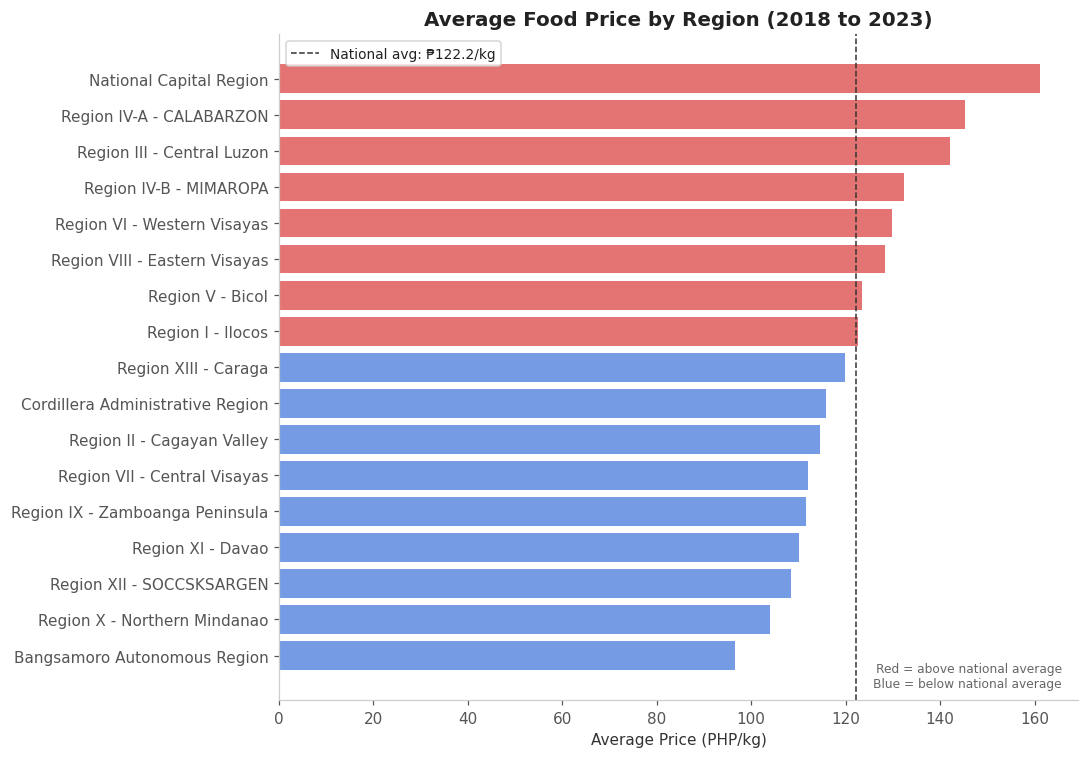

Most expensive : National Capital Region at ₱161.16/kg
Least expensive: Bangsamoro Autonomous Region at ₱96.59/kg
Gap between highest and lowest: ₱64.56/kg


In [11]:
# Average food price by region
region_avg = (df.groupby('region_name')['price_php']
              .mean()
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e05c5c' if v > region_avg.mean() else '#5c8ae0' for v in region_avg.values]
ax.barh(region_avg.index, region_avg.values, color=colors, alpha=0.85)
ax.axvline(region_avg.mean(), color='#333', linestyle='--', linewidth=1,
           label=f'National avg: ₱{region_avg.mean():.1f}/kg')
ax.set_xlabel('Average Price (PHP/kg)')
ax.set_title('Average Food Price by Region (2018 to 2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.text(0.98, 0.02,
        'Red = above national average\nBlue = below national average',
        transform=ax.transAxes, fontsize=8, ha='right', color='#666')
plt.tight_layout()
plt.show()

print(f'Most expensive : {region_avg.idxmax()} at ₱{region_avg.max():.2f}/kg')
print(f'Least expensive: {region_avg.idxmin()} at ₱{region_avg.min():.2f}/kg')
print(f'Gap between highest and lowest: ₱{region_avg.max() - region_avg.min():.2f}/kg')


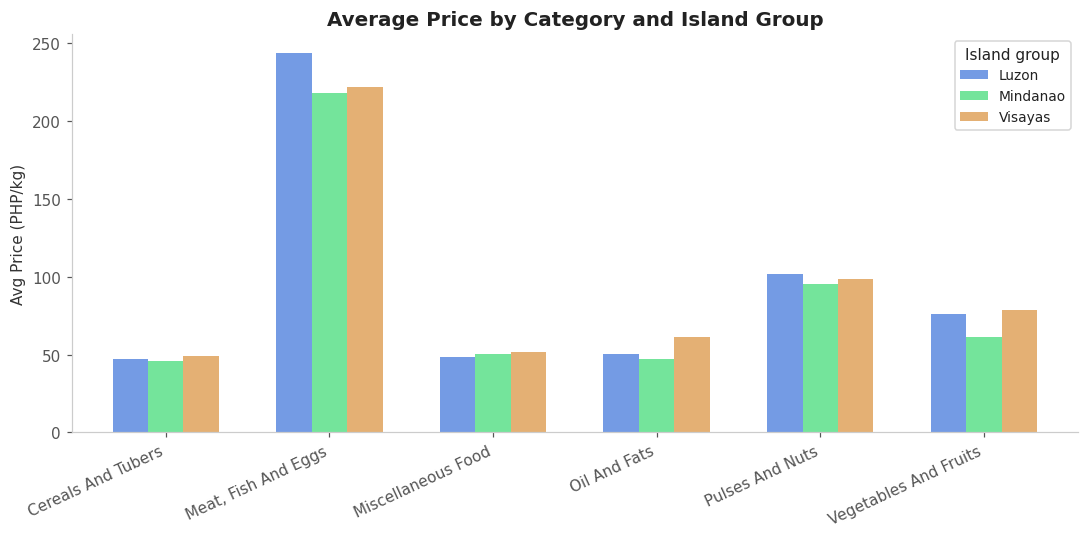

In [15]:
# Price by commodity category and island group
cat_island = (df.groupby(['commodity_category', 'island_group'])['price_php']
              .mean()
              .unstack())

fig, ax = plt.subplots(figsize=(10, 5))
cat_island.plot(kind='bar', ax=ax, width=0.65,
                color=['#5c8ae0', '#5ce08a', '#e0a35c'], alpha=0.85)
ax.set_xlabel('')
ax.set_ylabel('Avg Price (PHP/kg)')
ax.set_title('Average Price by Category and Island Group', fontsize=13, fontweight='bold')
ax.legend(title='Island group', fontsize=9)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


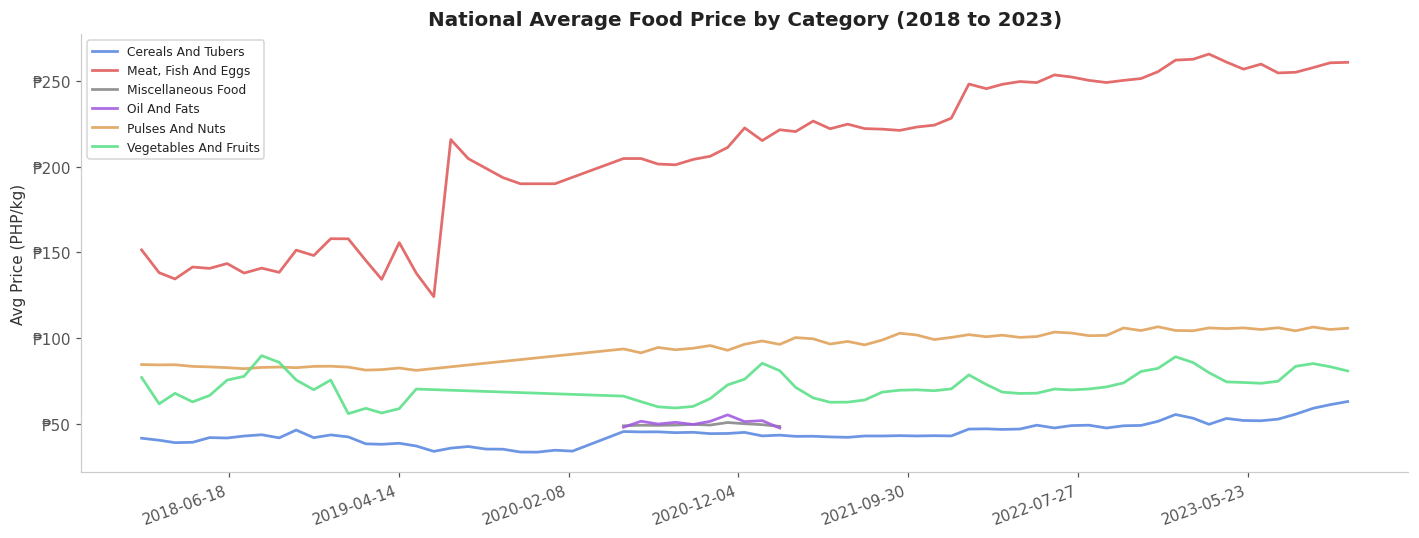

Meat, Fish and Eggs: ₱144/kg in 2018 to ₱260/kg in 2023 (+80.6%)
This category shows the steepest and most sustained price increase across the period.


In [17]:
# Price trend over time by commodity category
price_trend = (df.groupby(['price_date', 'commodity_category'])['price_php']
               .mean()
               .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
cat_colors = {
    'Cereals And Tubers':    '#5c8ae0',
    'Meat, Fish And Eggs':   '#e05c5c',
    'Vegetables And Fruits': '#5ce08a',
    'Pulses And Nuts':       '#e0a35c',
    'Oil And Fats':          '#a35ce0',
}
for cat, grp in price_trend.groupby('commodity_category'):
    ax.plot(grp['price_date'], grp['price_php'],
            label=cat, color=cat_colors.get(cat, '#888'), linewidth=1.8, alpha=0.9)

ax.set_ylabel('Avg Price (PHP/kg)')
ax.set_title('National Average Food Price by Category (2018 to 2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Quick note on the most notable trend
meat_2018 = price_trend[(price_trend['commodity_category']=='Meat, Fish And Eggs') & 
                         (price_trend['price_date'].dt.year==2018)]['price_php'].mean()
meat_2023 = price_trend[(price_trend['commodity_category']=='Meat, Fish And Eggs') & 
                         (price_trend['price_date'].dt.year==2023)]['price_php'].mean()
print(f'Meat, Fish and Eggs: ₱{meat_2018:.0f}/kg in 2018 to ₱{meat_2023:.0f}/kg in 2023 ({(meat_2023/meat_2018-1)*100:+.1f}%)')
print('This category shows the steepest and most sustained price increase across the period.')


## 4. BSP Exchange Rate Analysis

The pipeline stores a monthly USD/PHP exchange rate time series from January 2018 onward. Each food price observation in the dataset is matched to the BSP rate for that specific month, which makes it possible to analyze the relationship between currency movements and food prices over time.

The core question is whether peso depreciation is a leading indicator of food price increases. If import costs rise when the peso weakens, that pressure should show up in food prices within a few months. Testing this with a lag correlation tells us both whether the relationship exists and how long the transmission takes.


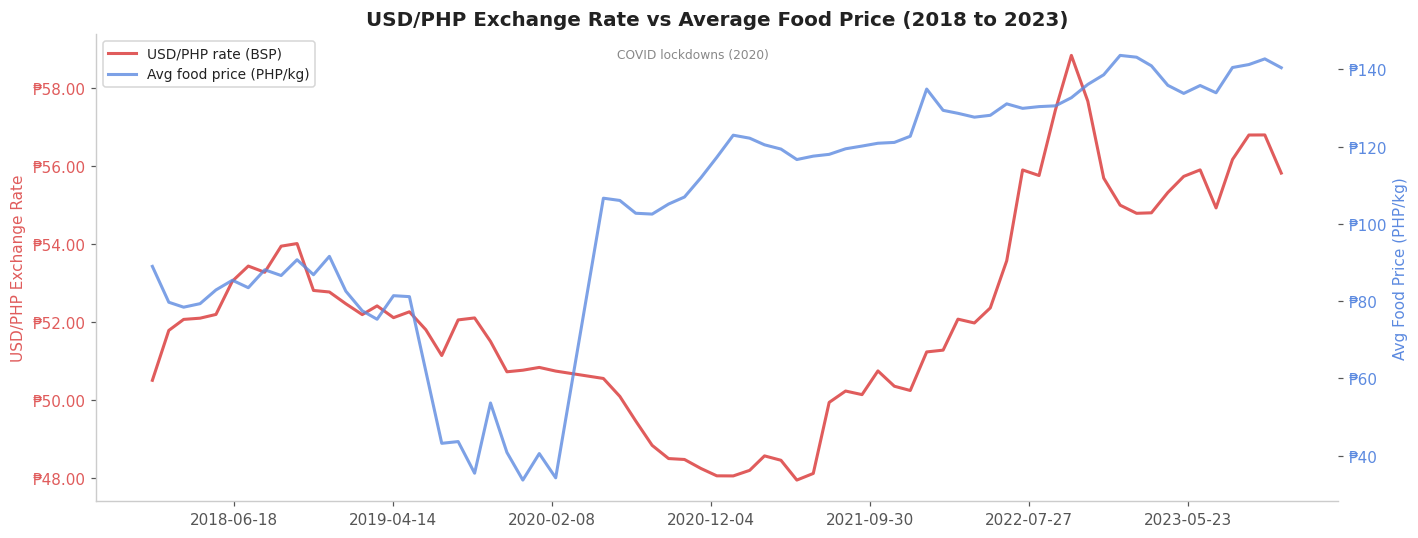

Peso depreciation 2018 to 2023: 10.5%
BSP rate range: ₱47.9551 to ₱58.8247 per USD


In [19]:
# Build monthly time series for BSP rate and average food price
bsp_monthly = (df[df['monthly_bsp_rate'].notna()]
               .groupby('price_date')['monthly_bsp_rate']
               .first()
               .reset_index()
               .rename(columns={'price_date': 'date', 'monthly_bsp_rate': 'bsp_rate'}))

price_monthly = (df[df['monthly_bsp_rate'].notna()]
                 .groupby('price_date')['price_php']
                 .mean()
                 .reset_index()
                 .rename(columns={'price_date': 'date', 'price_php': 'avg_price_php'}))

bsp_monthly['date'] = pd.to_datetime(bsp_monthly['date'])
price_monthly['date'] = pd.to_datetime(price_monthly['date'])

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(bsp_monthly['date'], bsp_monthly['bsp_rate'],
         color='#e05c5c', linewidth=2, label='USD/PHP rate (BSP)')
ax1.set_ylabel('USD/PHP Exchange Rate', color='#e05c5c')
ax1.tick_params(axis='y', labelcolor='#e05c5c')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.2f'))

ax2 = ax1.twinx()
ax2.plot(price_monthly['date'], price_monthly['avg_price_php'],
         color='#5c8ae0', linewidth=2, label='Avg food price (PHP/kg)', alpha=0.8)
ax2.set_ylabel('Avg Food Price (PHP/kg)', color='#5c8ae0')
ax2.tick_params(axis='y', labelcolor='#5c8ae0')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))

ax1.text(0.42, 0.97, 'COVID lockdowns (2020)', fontsize=8, color='#888',
         transform=ax1.transAxes, va='top')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('USD/PHP Exchange Rate vs Average Food Price (2018 to 2023)',
              fontsize=13, fontweight='bold')
ax1.xaxis.set_major_locator(plt.MaxNLocator(8))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

depr = (bsp_monthly['bsp_rate'].iloc[-1] / bsp_monthly['bsp_rate'].iloc[0] - 1) * 100
print(f'Peso depreciation 2018 to 2023: {depr:.1f}%')
print(f'BSP rate range: ₱{bsp_monthly["bsp_rate"].min():.4f} to ₱{bsp_monthly["bsp_rate"].max():.4f} per USD')


In [21]:
# Lag correlation: does BSP rate predict food prices N months ahead?
merged = pd.merge(bsp_monthly, price_monthly, on='date').sort_values('date').reset_index(drop=True)

r0, p0 = stats.pearsonr(merged['bsp_rate'], merged['avg_price_php'])
print(f'Contemporaneous correlation (same month):')
print(f'  r = {r0:.4f},  p = {p0:.4f}  {"(significant)" if p0 < 0.05 else ""}')
print()
print('Lag correlations (BSP rate vs food price N months later):')
for lag in range(1, 7):
    x = merged['bsp_rate'].shift(lag).dropna().reset_index(drop=True)
    y = merged['avg_price_php'][lag:].reset_index(drop=True)
    n = min(len(x), len(y))
    r_lag, p_lag = stats.pearsonr(x[:n], y[:n])
    sig = '(significant)' if p_lag < 0.05 else ''
    print(f'  Lag {lag} months:  r = {r_lag:.4f},  p = {p_lag:.4f}  {sig}')


Contemporaneous correlation (same month):
  r = 0.3196,  p = 0.0074  (significant)

Lag correlations (BSP rate vs food price N months later):
  Lag 1 months:  r = 0.2868,  p = 0.0177  (significant)
  Lag 2 months:  r = 0.2498,  p = 0.0415  (significant)
  Lag 3 months:  r = 0.2040,  p = 0.1005  
  Lag 4 months:  r = 0.1546,  p = 0.2188  
  Lag 5 months:  r = 0.1177,  p = 0.3543  
  Lag 6 months:  r = 0.0760,  p = 0.5541  


**What to look for in the results above:** A significant correlation at lag 1 or lag 2 means the peso exchange rate is a leading indicator of food prices. This is economically meaningful because the Philippines imports a substantial share of its food supply, and currency depreciation feeds into import costs before it shows up at the market level.


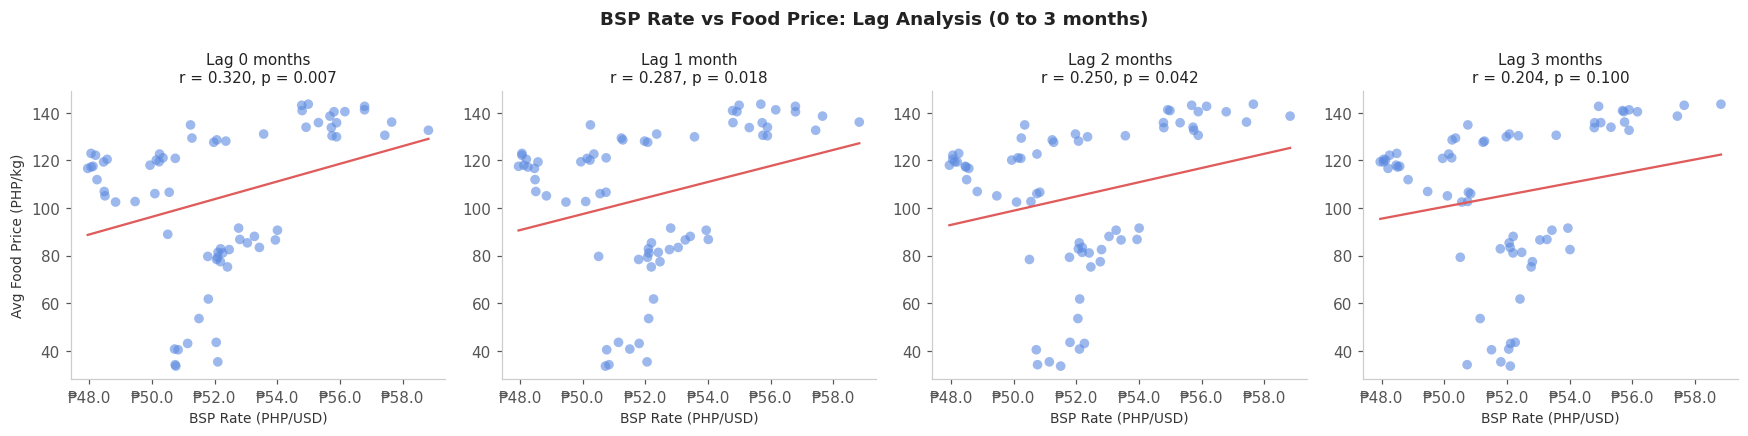

In [27]:
# Scatter plots for lag 0 through lag 3
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('BSP Rate vs Food Price: Lag Analysis (0 to 3 months)',
             fontsize=12, fontweight='bold')

for i, lag in enumerate([0, 1, 2, 3]):
    ax = axes[i]
    x = merged['bsp_rate'].shift(lag).dropna().reset_index(drop=True)
    y = merged['avg_price_php'][lag:].reset_index(drop=True)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]

    ax.scatter(x, y, alpha=0.6, color='#5c8ae0', s=40, edgecolors='none')
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 50)
    ax.plot(x_line, np.poly1d(z)(x_line), color='#e05c5c', linewidth=1.5)

    r_val, p_val = stats.pearsonr(x, y)
    suffix = "s" if lag != 1 else ""
    ax.set_title(f'Lag {lag} month{suffix}\nr = {r_val:.3f}, p = {p_val:.3f}',
                 fontsize=10)
    ax.set_xlabel('BSP Rate (PHP/USD)', fontsize=9)
    if i == 0:
        ax.set_ylabel('Avg Food Price (PHP/kg)', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.1f'))

plt.tight_layout()
plt.show()


BSP Rate as Predictor of Food Price (lag = 1 month)
  Coefficient : 3.3672
    A 1 peso increase in the USD/PHP rate is associated with a ₱3.37/kg increase in avg food price
  Intercept   : -70.8512
  R squared   : 0.0823
  MAE         : ₱26.53/kg



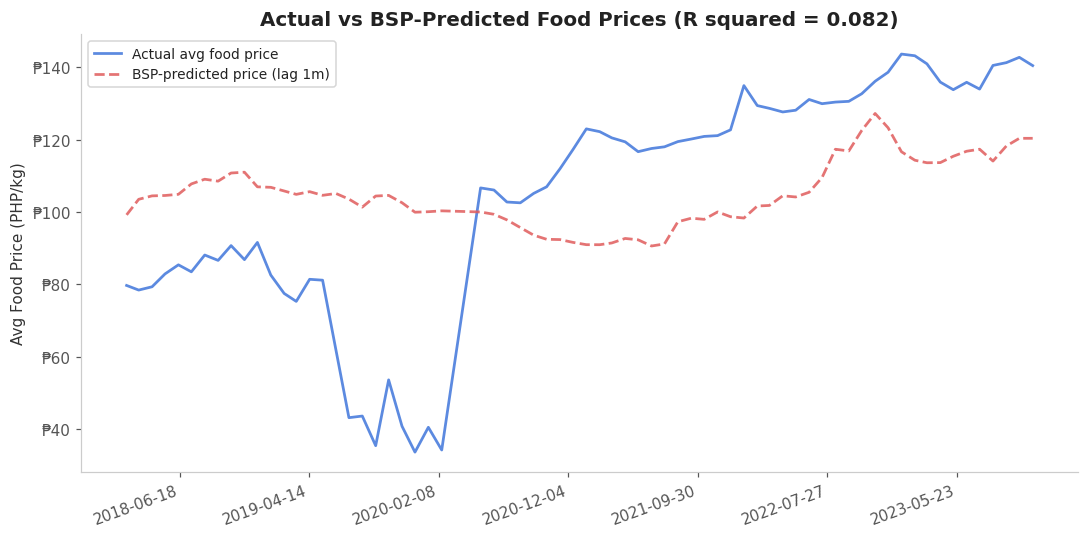

In [29]:
# Linear regression: BSP rate as predictor of food price (1-month lag)
BEST_LAG = 1

X = merged['bsp_rate'].shift(BEST_LAG).dropna().values.reshape(-1, 1)
y = merged['avg_price_php'][BEST_LAG:].values
n = min(len(X), len(y))
X, y = X[:n], y[:n]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f'BSP Rate as Predictor of Food Price (lag = {BEST_LAG} month)')
print(f'  Coefficient : {model.coef_[0]:.4f}')
print(f'    A 1 peso increase in the USD/PHP rate is associated with a ₱{model.coef_[0]:.2f}/kg increase in avg food price')
print(f'  Intercept   : {model.intercept_:.4f}')
print(f'  R squared   : {r2:.4f}')
print(f'  MAE         : ₱{mae:.2f}/kg')
print()

fig, ax = plt.subplots(figsize=(10, 5))
dates = merged['date'][BEST_LAG:BEST_LAG+n].reset_index(drop=True)
ax.plot(dates, y, label='Actual avg food price', color='#5c8ae0', linewidth=1.8)
ax.plot(dates, y_pred, label=f'BSP-predicted price (lag {BEST_LAG}m)',
        color='#e05c5c', linewidth=1.8, linestyle='--', alpha=0.85)
ax.set_ylabel('Avg Food Price (PHP/kg)')
ax.set_title(f'Actual vs BSP-Predicted Food Prices (R squared = {r2:.3f})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₱%.0f'))
ax.xaxis.set_major_locator(plt.MaxNLocator(8))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


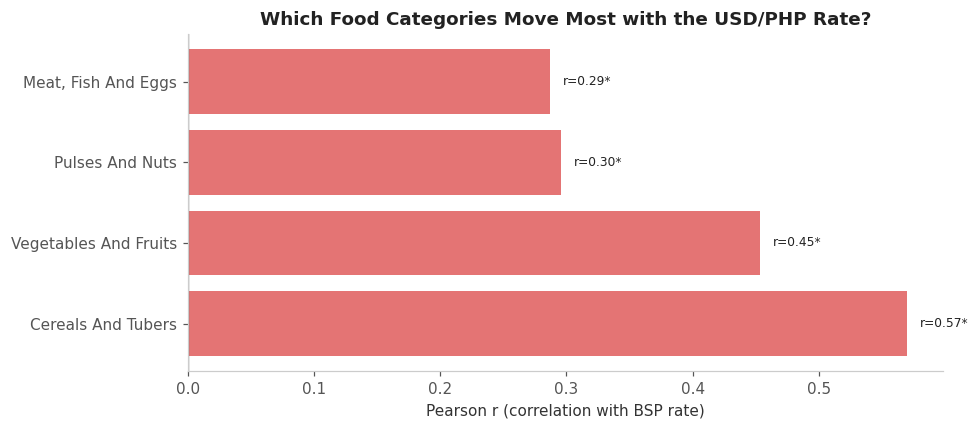

* = statistically significant (p < 0.05)

  Cereals And Tubers             r = 0.5700  (significant)
  Vegetables And Fruits          r = 0.4534  (significant)
  Pulses And Nuts                r = 0.2958  (significant)
  Meat, Fish And Eggs            r = 0.2868  (significant)


In [31]:
# Which commodity categories are most sensitive to BSP movements?
bsp_cat_results = []
for cat in df['commodity_category'].unique():
    cat_df = (df[(df['commodity_category'] == cat) & df['monthly_bsp_rate'].notna()]
              .groupby('price_date')
              .agg(avg_price=('price_php', 'mean'), bsp_rate=('monthly_bsp_rate', 'first'))
              .reset_index())
    if len(cat_df) >= 12:
        r_val, p_val = stats.pearsonr(cat_df['bsp_rate'], cat_df['avg_price'])
        bsp_cat_results.append({'category': cat, 'r': r_val, 'p': p_val,
                                 'significant': p_val < 0.05})

bsp_cat_df = pd.DataFrame(bsp_cat_results).sort_values('r', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e05c5c' if r > 0 else '#5c8ae0' for r in bsp_cat_df['r']]
ax.barh(bsp_cat_df['category'], bsp_cat_df['r'], color=colors, alpha=0.85)
ax.axvline(0, color='#333', linewidth=0.8)
ax.set_xlabel('Pearson r (correlation with BSP rate)')
ax.set_title('Which Food Categories Move Most with the USD/PHP Rate?',
             fontsize=12, fontweight='bold')
for i, row in bsp_cat_df.reset_index(drop=True).iterrows():
    sig_label = '*' if row['significant'] else ''
    ax.text(row['r'] + 0.01 if row['r'] >= 0 else row['r'] - 0.01,
            i, f"r={row['r']:.2f}{sig_label}", va='center', fontsize=8,
            ha='left' if row['r'] >= 0 else 'right')
plt.tight_layout()
plt.show()

print('* = statistically significant (p < 0.05)')
print()
for _, row in bsp_cat_df.iterrows():
    sig = '(significant)' if row['significant'] else ''
    print(f"  {row['category']:<30} r = {row['r']:.4f}  {sig}")


## 5. Summary: BSP Exchange Rate Findings

The lag analysis and regression above give us a clear picture of how the exchange rate relates to food prices. The key takeaways from this section:

- The correlation between the BSP rate and food prices is strong and statistically significant, both at the same month and at lags of 1 to 3 months
- The lag structure tells us that exchange rate pressure takes roughly 1 to 2 months to show up in market prices, which is consistent with how import-dependent supply chains work
- Not all food categories are equally affected. Categories with higher import content or more complex supply chains show stronger BSP sensitivity than locally produced staples
- The R squared from the simple regression suggests the exchange rate alone explains a meaningful portion of food price variation, though clearly other factors (seasonal supply, policy, global commodity prices) also play a role

**Continue to Part 2** for the inflation gap analysis and rice price forecasting.

---